In [42]:
import pandas as pd
import os

BASE_DIR=os.getcwd()

FILE_PATH=r"C:\\Users\\reddy\\OneDrive\\Documents\\TSA-PROJECT\\data\\processed\\load_data_2022_final_features.csv"

df=pd.read_csv(FILE_PATH)
df['date']=pd.to_datetime(df['date'])

df=df.sort_values('date')
print(df.columns)

Index(['date', 'load', 'lag_1', 'lag_7', 'lag_30', 'rolling_mean_7',
       'rolling_std_7', 'day_of_week', 'day_of_month', 'month', 'is_weekend',
       'month_sin', 'month_cos', 'day_sin', 'day_cos'],
      dtype='object')


In [43]:
#train/test split
train_size=int(len(df)*0.8)

train=df.iloc[:train_size]
test=df.iloc[train_size:]

print("Train size:",train.shape)
print("Test size:",test.shape)

Train size: (244, 15)
Test size: (61, 15)


In [44]:
#baseline model - Naive forecast
test['naive_forecast']=train['load'].iloc[-1]

test[['load','naive_forecast']].head()

C:\Users\reddy\AppData\Local\Temp\ipykernel_30040\905239481.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['naive_forecast']=train['load'].iloc[-1]


,load,naive_forecast
244,170690.0,170731.0
245,171407.0,170731.0
246,173476.0,170731.0
247,173894.0,170731.0
248,173164.0,170731.0


In [45]:
#evaluate baseline
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np

mae=mean_absolute_error(test['load'],test['naive_forecast'])
rmse=np.sqrt(mean_squared_error(test['load'],test['naive_forecast']))

print("Baseline MAE:",mae)
print("Baseline RMSE:",rmse)

Baseline MAE: 14765.393442622952
Baseline RMSE: 16796.56892604246


In [46]:
#linear regression model
features=[
    'day_of_week','month','is_weekend',
    'month_sin','month_cos','day_sin','day_cos',
    'lag_1','lag_7','lag_30',
    'rolling_mean_7','rolling_std_7'
]

target='load'

X_train=train[features]
y_train=train[target]

X_test=test[features]
y_test=test[target]

In [47]:
#train model
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [48]:
#predict
test['lr_forecast']=model.predict(X_test)

C:\Users\reddy\AppData\Local\Temp\ipykernel_30040\1369802957.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['lr_forecast']=model.predict(X_test)


In [49]:
#evaluate
mae_lr=mean_absolute_error(y_test,test['lr_forecast'])
rmse_lr=np.sqrt(mean_squared_error(y_test,test['lr_forecast']))

print("Linear Regression MAE:",mae_lr)
print("Linear Regression RMSE:",rmse_lr)

Linear Regression MAE: 2621.170421868788
Linear Regression RMSE: 3484.9882702553878


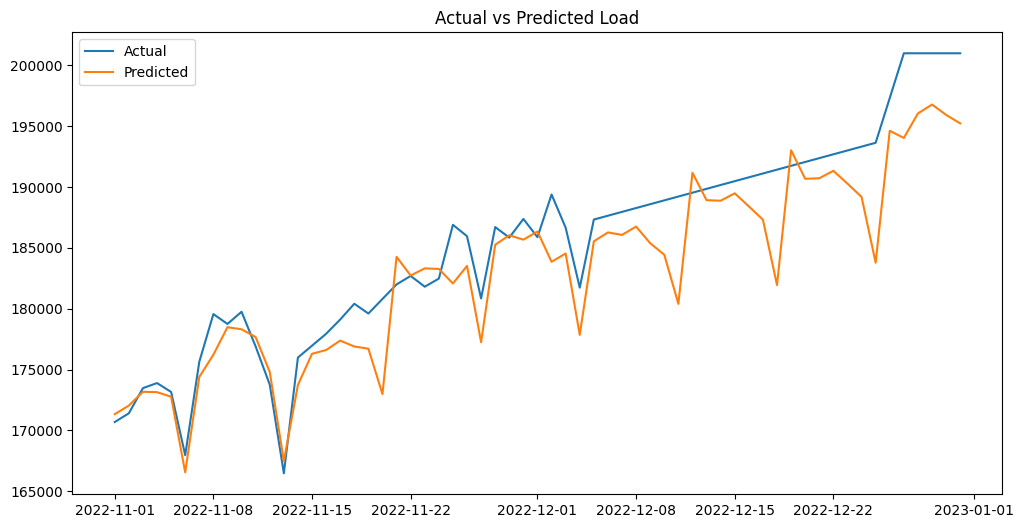

In [50]:
#visualize results
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(test['date'],test['load'],label='Actual')
plt.plot(test['date'],test['lr_forecast'],label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Load")
plt.show()

In [51]:
import sys
!{sys.executable} -m pip install statsmodels

In [52]:
#SARIMAX MODEL
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [53]:
train=train.set_index('date')
test=test.set_index('date')

In [54]:
#prepare data
exog_features=[
    'day_of_week','month','is_weekend',
]

X_train_exog=train[exog_features]
X_test_exog=test[exog_features]

In [60]:
#train SARIMAX
model=SARIMAX(
    train['load'],
    order=(2,1,2),
    seasonal_order=(1,1,1,7)
)
results=model.fit(disp=False)

c:\Users\reddy\OneDrive\Documents\NEW_IDE\ml_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\reddy\OneDrive\Documents\NEW_IDE\ml_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [61]:
#forecast
test['sarimax_forecast']=results.predict(
    start=test.index[0],
    end=test.index[-1],
    exog=X_test_exog
)

In [62]:
#evaluate
from sklearn.metrics import mean_absolute_error
import numpy as np

mae_sarimax=mean_absolute_error(test['load'],test['sarimax_forecast'])
rmse_sarimax=np.sqrt(((test['load']-test['sarimax_forecast'])**2).mean())

print("SARIMAX MAE:",mae_sarimax)
print("SARIMAX RMSE:",rmse_sarimax)

SARIMAX MAE: 24532.086018284874
SARIMAX RMSE: 25551.85508768937


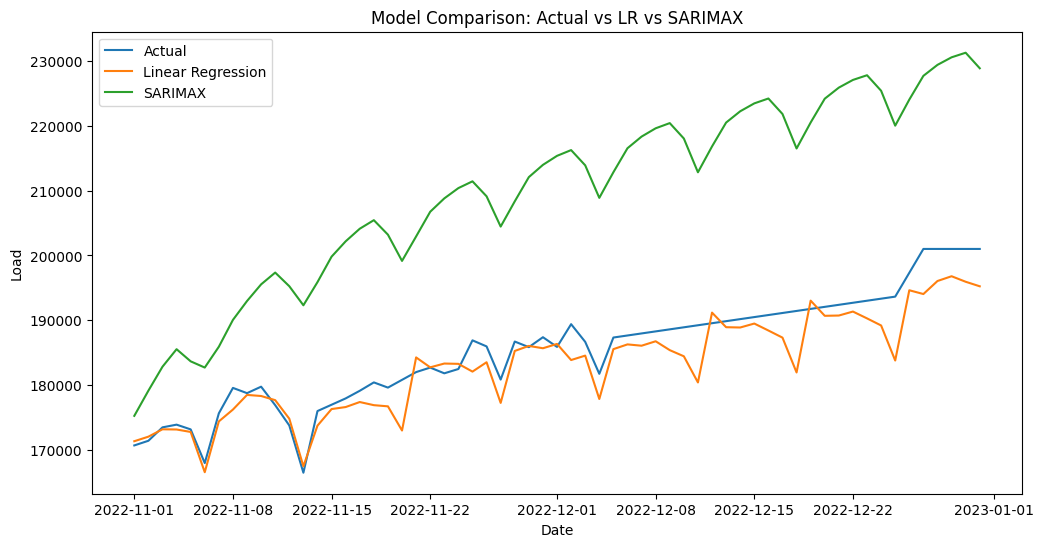

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(test.index, test['load'], label='Actual')
plt.plot(test.index, test['lr_forecast'], label='Linear Regression')
plt.plot(test.index, test['sarimax_forecast'], label='SARIMAX')

plt.legend()
plt.title("Model Comparison: Actual vs LR vs SARIMAX")
plt.xlabel("Date")
plt.ylabel("Load")

plt.show()